In [8]:
import pandas as pd
# ============================================================
# ÉTAPE 3 — CRÉATION DE LA VARIABLE CIBLE (LABELING)
# ============================================================

df_clean_capped = pd.read_csv('../data/processed/cleaned_data.csv')
df_labeled = df_clean_capped.copy()

# Plages médicales normales (basées sur valeurs de référence standards)
normal_ranges = {
    'ERY':   (4.0, 6.0),
    'HK':    (34, 50),
    'LEUKO': (4.0, 11.0),
    'HB':    (12, 18),
    'PLT':   (150, 450),
    'MCV':   (80, 100),
    'MCHC':  (32, 36),
    'MCH':   (27, 33),
    'RDW':   (11.5, 15.5)
}

# Calcul du score d'anomalie (vectorisé, pas de boucle)
df_labeled['anomaly_score'] = 0

for col, (low, high) in normal_ranges.items():
    df_labeled['anomaly_score'] += (
        (df_labeled[col] < low) | (df_labeled[col] > high)
    ).astype(int)

print("Distribution du score d'anomalie (0 à 9):")
print(df_labeled['anomaly_score'].value_counts().sort_index())

Distribution du score d'anomalie (0 à 9):
anomaly_score
0    143756
1     89360
2     54651
3     70312
4     66787
5     47175
6     30489
7     15256
8      5352
9       706
Name: count, dtype: int64


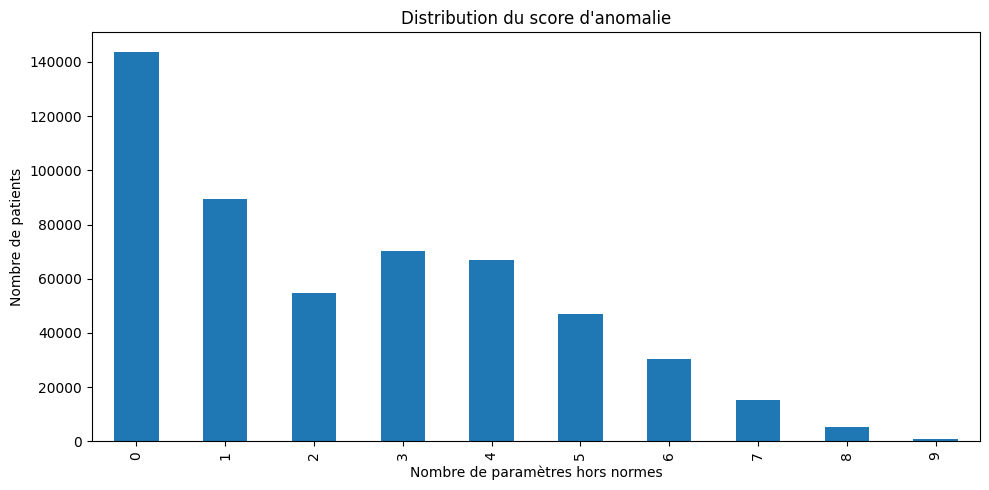

In [9]:
import matplotlib.pyplot as plt
# Visualiser la distribution du score
plt.figure(figsize=(10, 5))
df_labeled['anomaly_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution du score d\'anomalie')
plt.xlabel('Nombre de paramètres hors normes')
plt.ylabel('Nombre de patients')
plt.tight_layout()
plt.savefig('../figures/distribution_anomaly_score.png', dpi=150)
plt.show()

In [10]:
# Tester plusieurs seuils pour le label — IMPORTANT pour le rapport
print("=" * 60)
print("COMPARAISON DES SEUILS POUR LE LABEL")
print("=" * 60)

for threshold in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    label_temp = (df_labeled['anomaly_score'] >= threshold).astype(int)
    pct_anomaly = label_temp.mean() * 100
    print(f"Seuil >= {threshold} : "
          f"{label_temp.sum()} anomalies / {len(label_temp)} "
          f"({pct_anomaly:.2f}%) | Normal: {100-pct_anomaly:.2f}%")

COMPARAISON DES SEUILS POUR LE LABEL
Seuil >= 1 : 380088 anomalies / 523844 (72.56%) | Normal: 27.44%
Seuil >= 2 : 290728 anomalies / 523844 (55.50%) | Normal: 44.50%
Seuil >= 3 : 236077 anomalies / 523844 (45.07%) | Normal: 54.93%
Seuil >= 4 : 165765 anomalies / 523844 (31.64%) | Normal: 68.36%
Seuil >= 5 : 98978 anomalies / 523844 (18.89%) | Normal: 81.11%
Seuil >= 6 : 51803 anomalies / 523844 (9.89%) | Normal: 90.11%
Seuil >= 7 : 21314 anomalies / 523844 (4.07%) | Normal: 95.93%
Seuil >= 8 : 6058 anomalies / 523844 (1.16%) | Normal: 98.84%
Seuil >= 9 : 706 anomalies / 523844 (0.13%) | Normal: 99.87%
Seuil >= 10 : 0 anomalies / 523844 (0.00%) | Normal: 100.00%


In [16]:
# Choix du seuil final — à ajuster selon les résultats ci-dessus
# Recommandation : un seuil donnant entre 10% et 30% d'anomalies
# est gérable pour le ML (pas trop déséquilibré)

THRESHOLD = 4

df_labeled['label'] = (df_labeled['anomaly_score'] >= THRESHOLD).astype(int)

print(f"\nSeuil retenu: >= {THRESHOLD}")
print(df_labeled['label'].value_counts())
print(f"\nProportion d'anomalies: {df_labeled['label'].mean()*100:.2f}%")


Seuil retenu: >= 4
label
0    358079
1    165765
Name: count, dtype: int64

Proportion d'anomalies: 31.64%


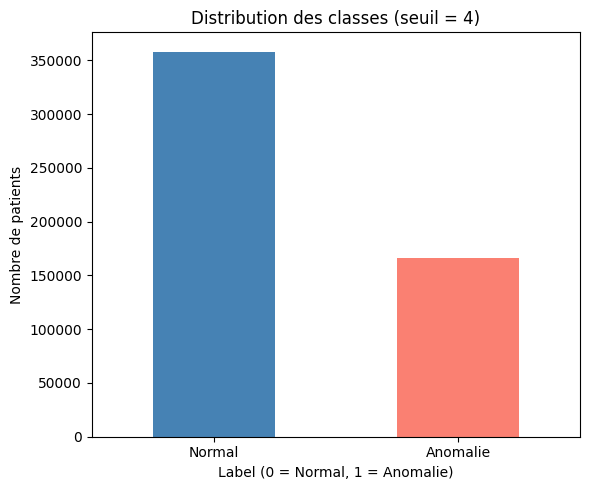

In [15]:
# Visualisation finale de la distribution des classes
plt.figure(figsize=(6, 5))
df_labeled['label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title(f'Distribution des classes (seuil = {THRESHOLD})')
plt.xlabel('Label (0 = Normal, 1 = Anomalie)')
plt.ylabel('Nombre de patients')
plt.xticks([0, 1], ['Normal', 'Anomalie'], rotation=0)
plt.tight_layout()
plt.savefig('../figures/distribution_classes.png', dpi=150)
plt.show()

In [17]:
# Sauvegarder le dataset avec labels
df_labeled.to_csv('../data/processed/labeled_data.csv', index=False)
print("✅ Dataset avec labels sauvegardé")
df_labeled.head()

✅ Dataset avec labels sauvegardé


,ERY,HK,LEUKO,HB,PLT,MCV,MCHC,MCH,RDW,anomaly_score,label
0,4.5,40.7,8.5,13.7,154,90.4,33.7,30.4,13.2,0,0
1,4.2,36.8,11.8,12.9,255,87.4,35.1,30.6,12.7,1,0
2,4.3,37.4,8.5,12.7,310,86.4,33.9,29.3,13.0,0,0
3,4.3,36.4,7.7,13.3,221,84.4,36.6,30.9,13.1,1,0
4,4.1,37.1,10.8,12.3,198,91.3,33.2,30.3,13.5,0,0


In [18]:
print("✅ Étape 3 terminée — Dataset avec labels créé et sauvegardé")

✅ Étape 3 terminée — Dataset avec labels créé et sauvegardé
